In [1]:
import os
import re
import concurrent.futures as conc
from pathlib import Path

import pandas as pd
import numpy as np

import vtk
from vtk.util.numpy_support import vtk_to_numpy

from scipy.spatial import distance_matrix

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn import metrics

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pyvista as pv

In [19]:
import numpy as np
import ipywidgets as ipyw
import matplotlib.pyplot as plt
%matplotlib inline

class ImageSliceViewer3D:
    """ 
    ImageSliceViewer3D is for viewing volumetric image slices in jupyter or
    ipython notebooks. 
    
    User can interactively change the slice plane selection for the image and 
    the slice plane being viewed. 

    Argumentss:
    Volume = 3D input image
    figsize = default(8,8), to set the size of the figure
    cmap = default('plasma'), string for the matplotlib colormap. You can find 
    more matplotlib colormaps on the following link:
    https://matplotlib.org/users/colormaps.html
    
    """
    
    def __init__(self, volume, figsize=(8,8), cmap='plasma'):
        self.volume = volume
        self.figsize = figsize
        self.cmap = cmap
        self.v = [np.min(volume), np.max(volume)]
        
        # Call to select slice plane
        ipyw.interact(self.view_selection, view=ipyw.RadioButtons(
            options=['x-y','y-z', 'z-x'], value='x-y', 
            description='Slice plane selection:', disabled=False,
            style={'description_width': 'initial'}))
    
    def view_selection(self, view):
        # Transpose the volume to orient according to the slice plane selection
        orient = {"y-z":[1,2,0], "z-x":[2,0,1], "x-y": [0,1,2]}
        self.vol = np.transpose(self.volume, orient[view])
        maxZ = self.vol.shape[2] - 1
        
        # Call to view a slice within the selected slice plane
        ipyw.interact(self.plot_slice, 
            z=ipyw.IntSlider(min=0, max=maxZ, step=1, continuous_update=False, 
            description='Image Slice:'))
        
    def plot_slice(self, z):
        # Plot slice for the given plane and slice
        self.fig = plt.figure(figsize=self.figsize)
        plt.imshow(self.vol[:,:,z], cmap=plt.get_cmap(self.cmap), 
            vmin=self.v[0], vmax=self.v[1])

In [20]:
class Frame:
    def __init__(self, path, dim=(100, 100, 100)):
        reader = vtk.vtkStructuredPointsReader()
        reader.SetFileName(path)
        reader.ReadAllScalarsOn()
        reader.Update()
        out = reader.GetOutput()
        d = out.GetPointData()
        names = [d.GetArrayName(i) for i in range(3)] 
        fields =  {n: vtk_to_numpy(d.GetArray(n)) for n in names} 
        types, cells = fields['CellType'] , fields['CellId']
        
        self.types = types.reshape(*dim)
        self.cells = cells.reshape(*dim)
        self.mcs = int(re.search('Step_(\d+).vtk', path).groups()[0])
        self.dim = dim
        
    def as_points(self):
        # returns the cells as 3D points
        dim = np.array(self.dim)
        points = np.vstack(np.unravel_index(np.arange(dim.prod()), dim))
        return points.T
        
    def show(self):
        # shows this frame in an ipyvolume frame
        points = self.as_points()
        for t in np.unique(self.types):
            fig = ip
            ipv.quickscatter(celldf.x.values, celldf.y.values, celldf.z.values, size=1, color=celldf.type, marker="box")
            
    def cluster(self, eps=2):
        points = self.as_points()
        types = self.types.flatten()
        cells = points[types != 0]
        celltypes = types[types != 0]
        db = DBSCAN(eps=eps, min_samples=10).fit(cells)
        core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
        core_samples_mask[db.core_sample_indices_] = True
        labels = db.labels_
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise_ = list(labels).count(-1)

        unique_labels = set(labels)
        colors = [plt.cm.Spectral(each)
                  for each in np.linspace(0, 1, len(unique_labels))]

        cluster = None
        for k, col in zip(unique_labels, colors):
            if k == -1:
                # Black used for noise.
                col = [0, 0, 0, 1]

            class_member_mask = (labels == k)

            xyz = cells[class_member_mask & core_samples_mask]
            if cluster is None or len(cluster) < len(xyz):
                cluster = xyz

        return np.array(cluster)

    def variance_ratio(self, plot=False):
        points = self.cluster()
        vol = points.shape[0]
        #max_d = distance_matrix(points, points).max()
        com = np.mean(points, axis=0)
        model = PCA(n_components=2)
        res = model.fit(points)
        if plot:
            fig = plt.figure()
            ax = fig.add_subplot(projection='3d')
            ax.scatter3D(points[:, 0], points[:, 1], points[:, 2], alpha=0.05)
            comp = (res.components_.T * res.explained_variance_).T
            ax.quiver3D(com[0], com[1], com[2], comp[0, 0], comp[0, 1], comp[0, 2], color='red')
            ax.quiver3D(com[0], com[1], com[2], comp[1, 0], comp[1, 1], comp[1, 2], color='green')
        return vol*(res.explained_variance_ratio_[0]/res.explained_variance_ratio_[1])
            
        
class Movie:
    def __init__(self, path):
        self.path = os.path.join(path, 'LatticeData')
        files = os.listdir(self.path)
        #print(f'reading {len(files)} frames from {self.path}')
        
        with conc.ProcessPoolExecutor() as ex:
            frames = ex.map(Frame, [os.path.join(self.path, file) for file in files if file.endswith('.vtk')])
            self.frames = sorted(frames, key=lambda x: x.mcs)

        self.t_max = len(self.frames)-1
    
    def frame_by_mcs(self, t):
        for frame in self.frames:
            if frame.mcs == t:
                return frame
        return None
    def frame_by_idx(self, i):
        if i >= 0 and i < len(self.frames):
            return self.frames[i] 
        return None
    
    def frames(self):
        return self.frames
    
    def variance_ratios(self):
        return [f.variance_ratio() for f in self.frames]

In [47]:
paths = ['../paper_revision/three_layer_control/gen_001/sim_000/', '../paper_revision/three_layer_control/gen_001/sim_001/']

In [48]:
movies = [Movie(path) for path in paths]

In [54]:
f = movies[0].frame_by_mcs(30000)

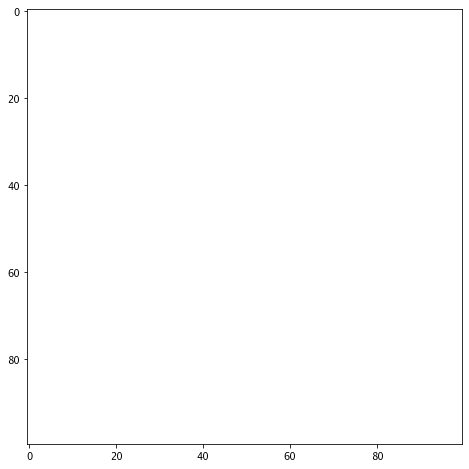

In [55]:
from matplotlib.colors import ListedColormap
viewer = ImageSliceViewer3D(f.types, cmap=ListedColormap(['white', 'yellow', 'green', 'blue', 'red']))

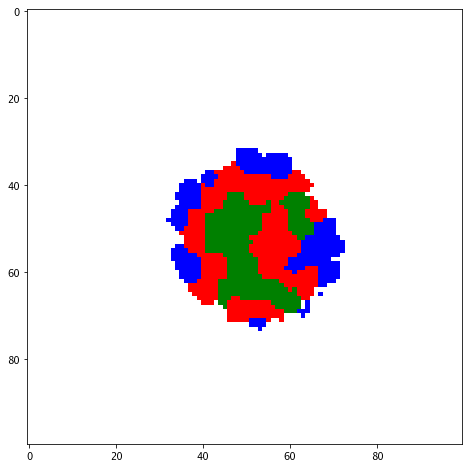

In [67]:
viewer.plot_slice(50)

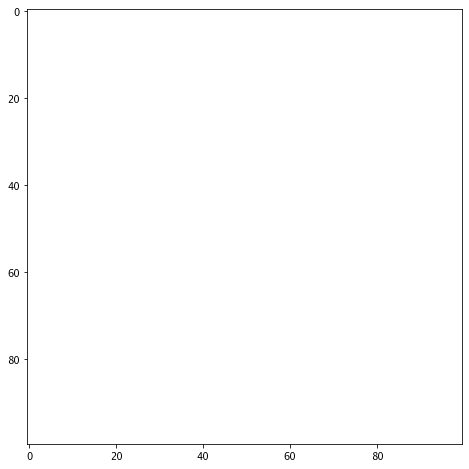

In [68]:
viewer2 = ImageSliceViewer3D(movies[1].frame_by_mcs(30000).types, cmap=ListedColormap(['white', 'yellow', 'green', 'blue', 'red']))

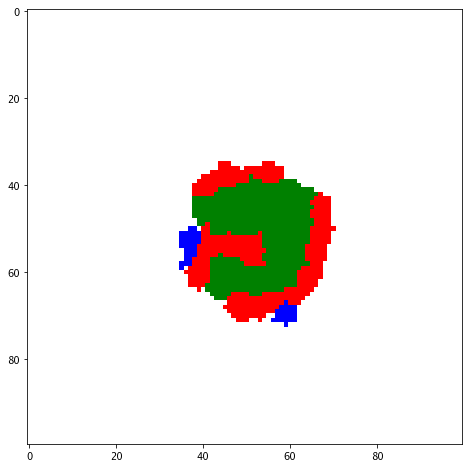

In [82]:
viewer2.plot_slice(55)

In [4]:
paths = [Path(f'../{exp}/gen_001/').resolve() for exp in ['threshold10k', 'threshold4k', 'blobtest']]

In [5]:
movies = {}
with conc.ProcessPoolExecutor() as ex:
    for path in paths:
        movies[path] = ex.map(Movie, [sim for sim in path.iterdir() if sim.is_dir()])

In [6]:
clusters = {}
for path, movie in movies.items():
    name = path.parent.name
    print(name)
    clusters[name] = [[f.cluster() for f in m.frames] for m in movie if len(m.frames) == 26]

threshold10k
threshold4k
blobtest


In [47]:
def fitness(points):
    '''
    fitness of a single frame, where points is an (n x 3) array of pixels
    '''
    vol = points.shape[0]
    max_d = distance_matrix(points, points).max()
    com = np.mean(points, axis=0)
    model = PCA(n_components=2)
    res = model.fit(points)
    return max_d/pow(vol, 1/3)*(res.explained_variance_ratio_[0]/res.explained_variance_ratio_[1])

In [48]:
a = [1, 2, 3]

In [50]:
rows = []

In [52]:
for name, sims in clusters.items():
    for s in range(len(sims)):
        f = fitness(sims[s][-1])
        rows.append([name, s, t, f])

In [53]:
fdf = pd.DataFrame(rows, columns=['experiment', 'sim', 'frame', 'fitness'])

In [64]:
plt.figure()
sns.barplot(x='experiment', y='fitness', data=fdf)
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [33]:
df = pd.DataFrame(rows, columns=['experiment', 'sim', 'frame', 'vol', 'elongation'])

In [45]:
df[df.frame.eq(df.frame.max())]

,experiment,sim,frame,vol,elongation
25,threshold10k,0,25,16361,5.185604
51,threshold10k,1,25,17826,5.502470
77,threshold10k,2,25,16574,1.618101
103,threshold10k,3,25,17159,3.974209
129,threshold10k,4,25,15622,5.070800
...,...,...,...,...,...
3301,blobtest,11,25,22221,2.322391
3327,blobtest,12,25,17025,1.553191
3353,blobtest,13,25,18347,2.441695
3379,blobtest,14,25,19476,2.924145


In [46]:
fig, ax = plt.subplots()
for experiment, chunk in df[df.frame.eq(df.frame.max())].groupby('experiment'):
    ax.scatter(chunk['vol'], chunk['elongation'], label=experiment)
plt.xlabel('volume')
plt.ylabel('ratio')
plt.legend()
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [43]:
# libraries
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
 
# plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
i = 0
colors = ['blue', 'orange', 'green']
for experiment, chunk in df.groupby('experiment'):
    ax.scatter(chunk['frame'], chunk['vol'], chunk['elongation'], c=colors[i], label=experiment)
    i += 1
plt.xlabel('frame')
plt.ylabel('volume')
ax.set_zlabel('ratio')
plt.legend()
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [6]:
fitnesses = {}
for path, movie in movies.items():
    name = path.parent.name
    print(name)
    fitnesses[name] = [m.variance_ratios() for m in movie if len(m.frames) == 26]

threshold10k
threshold4k
blobtest


threshold10k 51 [26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26]
threshold4k 64 [26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26]
blobtest 16 [26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26]


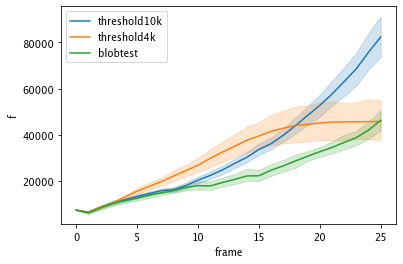

In [20]:
for name, fitness in fitnesses.items():
    print(name, len(fitness), [len(t) for t in fitness])
    rows = []
    for i in range(len(fitness)):
        for t in range(len(fitness[i])):
            rows.append([i, t, fitness[i][t]])
    df = pd.DataFrame(rows, columns=['sim', 'frame', 'f'])
    sns.lineplot(data=df, x='frame', y='f', label=name)
plt.legend()
plt.savefig('metric_test.png', dpi=300)

In [5]:
def plot(points, types):
    """
    make sure types is flat
    """
    colors = {0: 'gray', 1: 'yellow', 2: 'green', 3: 'blue', 4: 'red'}
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.grid(False)
    for t in np.unique(types):
        if t != 0:
            pts = points[types == t]
            ax.scatter3D(pts[:, 0], pts[:, 1], pts[:, 2], c=colors[t], marker='s', s=50)
    fig.show()